In [26]:
 # Cell 1 Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ast
from shapely.geometry import Polygon, Point
import re

# Load final_cleaned_boundaries4.csv
df_boundaries = pd.read_csv("/kaggle/input/final-cleaned-boundaries4/final_cleaned_boundaries4.csv")
df_boundaries["Boundaries_X"] = df_boundaries["Boundaries_X"].apply(ast.literal_eval)
df_boundaries["Boundaries_Y"] = df_boundaries["Boundaries_Y"].apply(ast.literal_eval)
df_boundaries["polygon"] = df_boundaries.apply(lambda row: list(zip(row["Boundaries_X"], row["Boundaries_Y"])), axis=1)
df_boundaries = df_boundaries[df_boundaries["polygon"].apply(lambda p: len(p) >= 3)].reset_index(drop=True)

# Load merfish_barcodes_example.csv
df_merfish = pd.read_csv(
    "/kaggle/input/merfish-origin/Merfish_Origin/merfish_barcodes_example.csv",
    usecols=["Gene_name", "Cell_name", "Centroid_X", "Centroid_Y"]
)
# Remove Blank-1 to Blank-5 molecules
df_merfish = df_merfish[~df_merfish["Gene_name"].isin(["Blank-1", "Blank-2", "Blank-3", "Blank-4", "Blank-5"])]


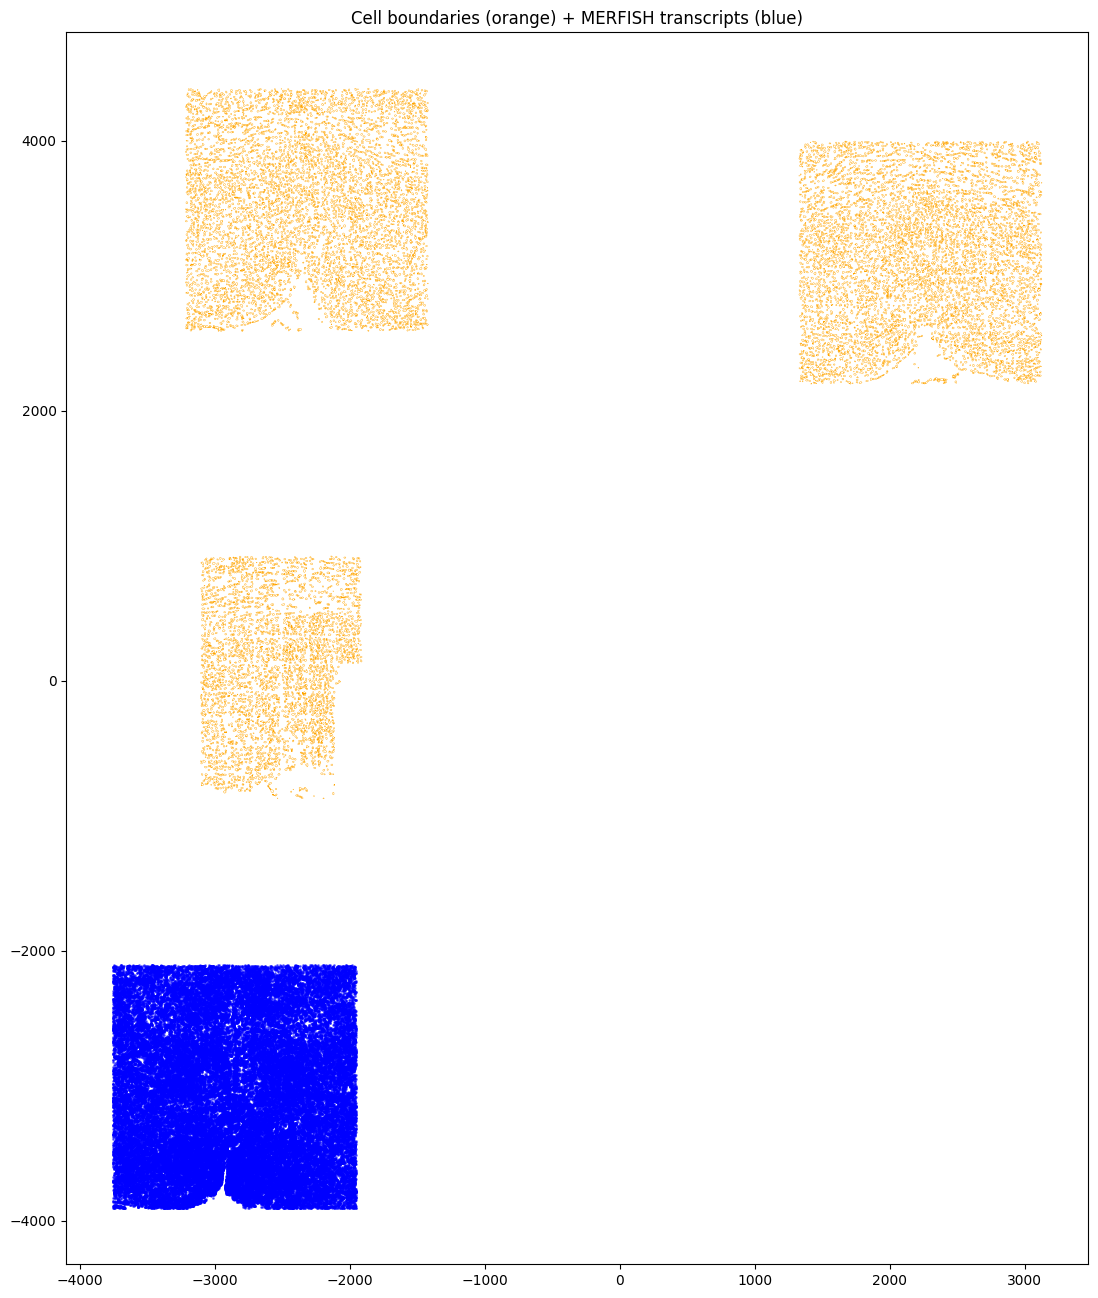

In [27]:
#Cell 2 Plot every cell boundary (light grey) and a sample of transcript dots (blue)
fig, ax = plt.subplots(figsize=(16, 16))

# --- plot cell polygons ---
for poly in df_boundaries["polygon"]:
    patch = mpatches.Polygon(poly, closed=True,
                             edgecolor="orange", facecolor="none",
                             linewidth=0.3)
    ax.add_patch(patch)

# --- plot transcript centroids ---
# (sub-sample to avoid millions of points slowing the plot)
sample = df_merfish.sample(
    n=min(100_000, len(df_merfish)), random_state=0
)

ax.scatter(sample["Centroid_X"],
           sample["Centroid_Y"],
           s=1, color="blue", alpha=0.5)

ax.set_aspect("equal")
ax.set_title("Cell boundaries (orange) + MERFISH transcripts (blue)")
plt.show()


In [28]:
#Cell 3 Check coordinate ranges for each dataset
print("Moffitt X range:", df_boundaries["Centroid_X"].min(), "to", df_boundaries["Centroid_X"].max())
print("MERFISH X range:", df_merfish["Centroid_X"].min(),  "to", df_merfish["Centroid_X"].max())


Moffitt X range: -3214.791805 to 3124.249209
MERFISH X range: -3756.099 to -1956.101


In [29]:
# Cell 4 Chunk 1: Load MERFISH & Moffitt ---
# Paths (update only if your filenames change)
moffitt_path = "/kaggle/input/final-cleaned-boundaries4/final_cleaned_boundaries4.csv"
merfish_path = "/kaggle/input/merfish-origin/Merfish_Origin/merfish_barcodes_example.csv"

# Load CSVs
df_moffitt = pd.read_csv(moffitt_path)
df_merfish = pd.read_csv(merfish_path)
df_merfish = df_merfish[~df_merfish["Gene_name"].str.startswith("Blank")]

# --- Prepare Moffitt polygons ---
# Boundaries_X / Boundaries_Y are stringified lists → convert to real lists
df_moffitt["Boundaries_X"] = df_moffitt["Boundaries_X"].apply(ast.literal_eval)
df_moffitt["Boundaries_Y"] = df_moffitt["Boundaries_Y"].apply(ast.literal_eval)

# Build Polygon objects for plotting later
df_moffitt["polygon"] = [
    Polygon(list(zip(x, y))) for x, y in zip(df_moffitt["Boundaries_X"],
                                             df_moffitt["Boundaries_Y"])
]

# --- Prepare MERFISH centroids ---
# Keep only centroid columns for speed
df_merfish_cent = df_merfish[["Centroid_X", "Centroid_Y"]].copy()


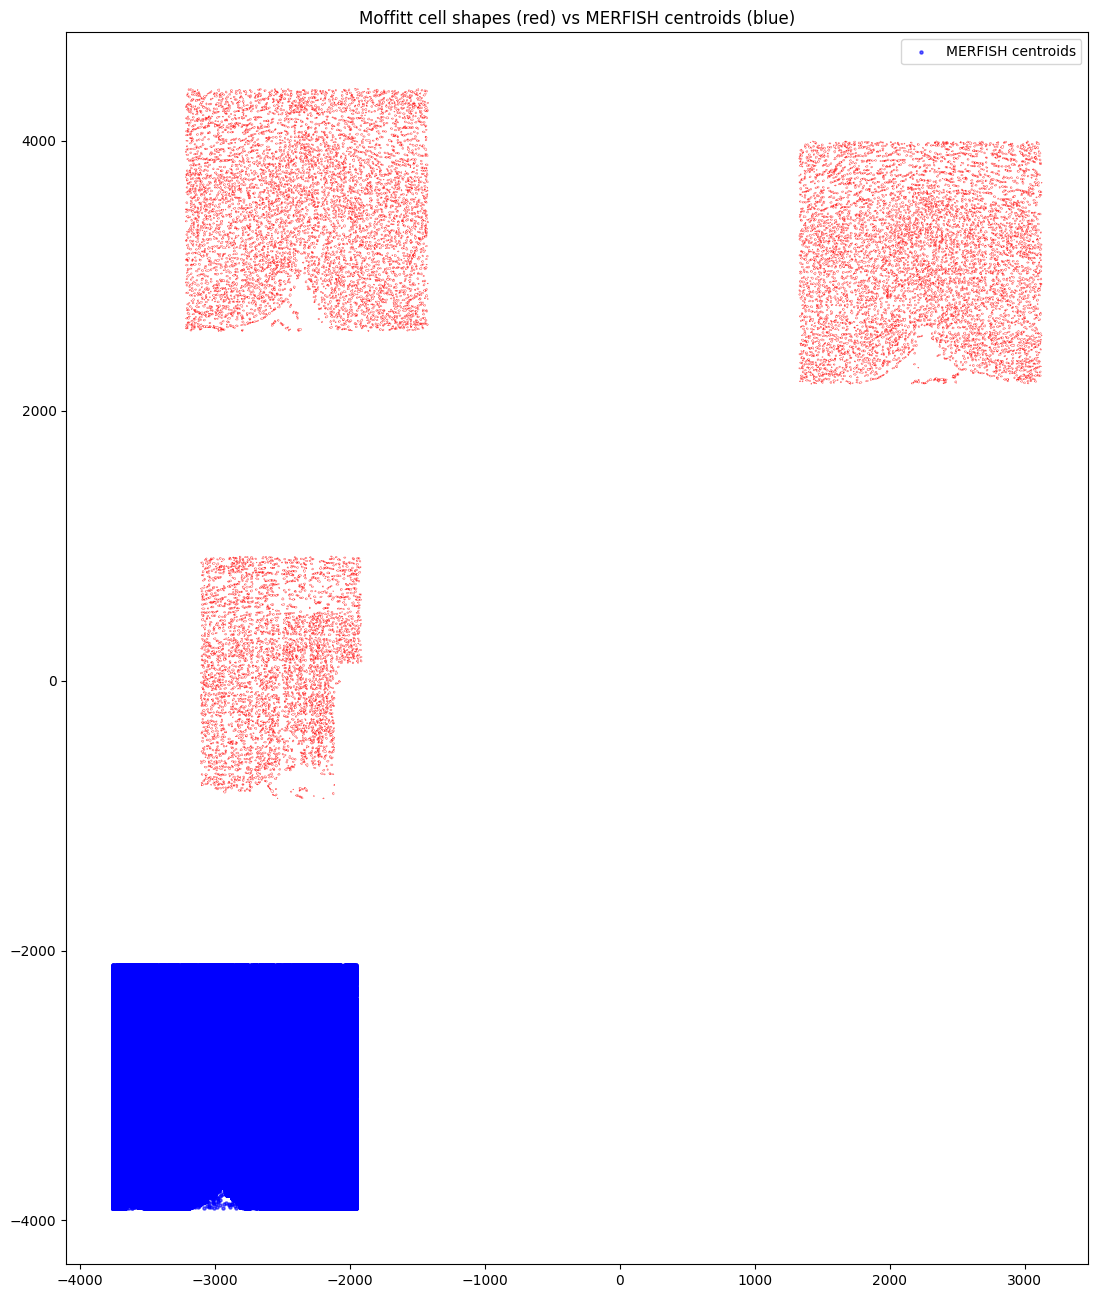

In [30]:
# Cell 5 Chunk 2: Visualize together ---
fig, ax = plt.subplots(figsize=(16, 16))

# Plot Moffitt polygons (red outlines, no fill)
for poly in df_moffitt["polygon"]:
    x, y = poly.exterior.xy
    ax.plot(x, y, lw=0.4, color="red", alpha=0.6)

# Plot MERFISH centroids (blue dots)
ax.scatter(
    df_merfish_cent["Centroid_X"],
    df_merfish_cent["Centroid_Y"],
    s=5,              # dot size
    color="blue",
    alpha=0.6,
    label="MERFISH centroids",
)

ax.set_aspect("equal")
ax.set_title("Moffitt cell shapes (red) vs MERFISH centroids (blue)")
ax.legend(loc="upper right")
plt.show()


In [31]:
# Cell 6 Load MERFISH and cell boundary datasets
df_merfish = pd.read_csv("/kaggle/input/merfish-origin/Merfish_Origin/merfish_barcodes_example.csv")
df_boundaries = pd.read_csv("/kaggle/input/merfish-origin/Merfish_Origin/cellboundaries_example_animal.csv")
df_merfish = df_merfish[~df_merfish["Gene_name"].str.startswith("Blank")]

# Drop MERFISH rows that have no Cell_name
before = len(df_merfish)
df_merfish = df_merfish[df_merfish["Cell_name"].notna()].copy()
after = len(df_merfish)

# Print counts before and after cleaning
print(f"MERFISH rows before: {before}")
print(f"MERFISH rows after removing empty Cell_name: {after}")


MERFISH rows before: 3728169
MERFISH rows after removing empty Cell_name: 1920853


In [32]:
# ✅ Check for remaining blanks before proceeding
print(df_merfish["Gene_name"].value_counts().loc[lambda x: x.index.str.startswith("Blank")])


Series([], Name: count, dtype: int64)


In [33]:
# Cell 7 Merge MERFISH molecules with boundaries using Cell_name ↔ feature_uID
df_merged = df_merfish.merge(
    df_boundaries[["feature_uID", "boundaryX", "boundaryY"]],
    left_on="Cell_name",
    right_on="feature_uID"
)

# Print merge results
print(f"Merged rows (molecules with matching cell boundaries): {len(df_merged):,}")
print(f"Unique matched parent cells: {df_merged['Cell_name'].nunique():,}")

# Check if all Cell_name and feature_uID are identical in merged rows
mismatch = (df_merged["Cell_name"] != df_merged["feature_uID"]).sum()
print(f"Mismatched Cell_name vs feature_uID rows: {mismatch}")


Merged rows (molecules with matching cell boundaries): 1,894,162
Unique matched parent cells: 6,412
Mismatched Cell_name vs feature_uID rows: 0


In [34]:
# Cell 8 Convert boundary strings from semicolon format to proper Python list format
df_merged["boundaryX"] = df_merged["boundaryX"].apply(lambda x: str([float(i) for i in str(x).split(";")]))
df_merged["boundaryY"] = df_merged["boundaryY"].apply(lambda x: str([float(i) for i in str(x).split(";")]))

# Drop the duplicate column since Cell_name equals feature_uID
df_merged.drop(columns=["feature_uID"], inplace=True)

# Save the cleaned merged DataFrame
df_merged.to_csv("merged_molecules_boundaries.csv", index=False)
print("Saved merged_molecules_boundaries.csv")


Saved merged_molecules_boundaries.csv


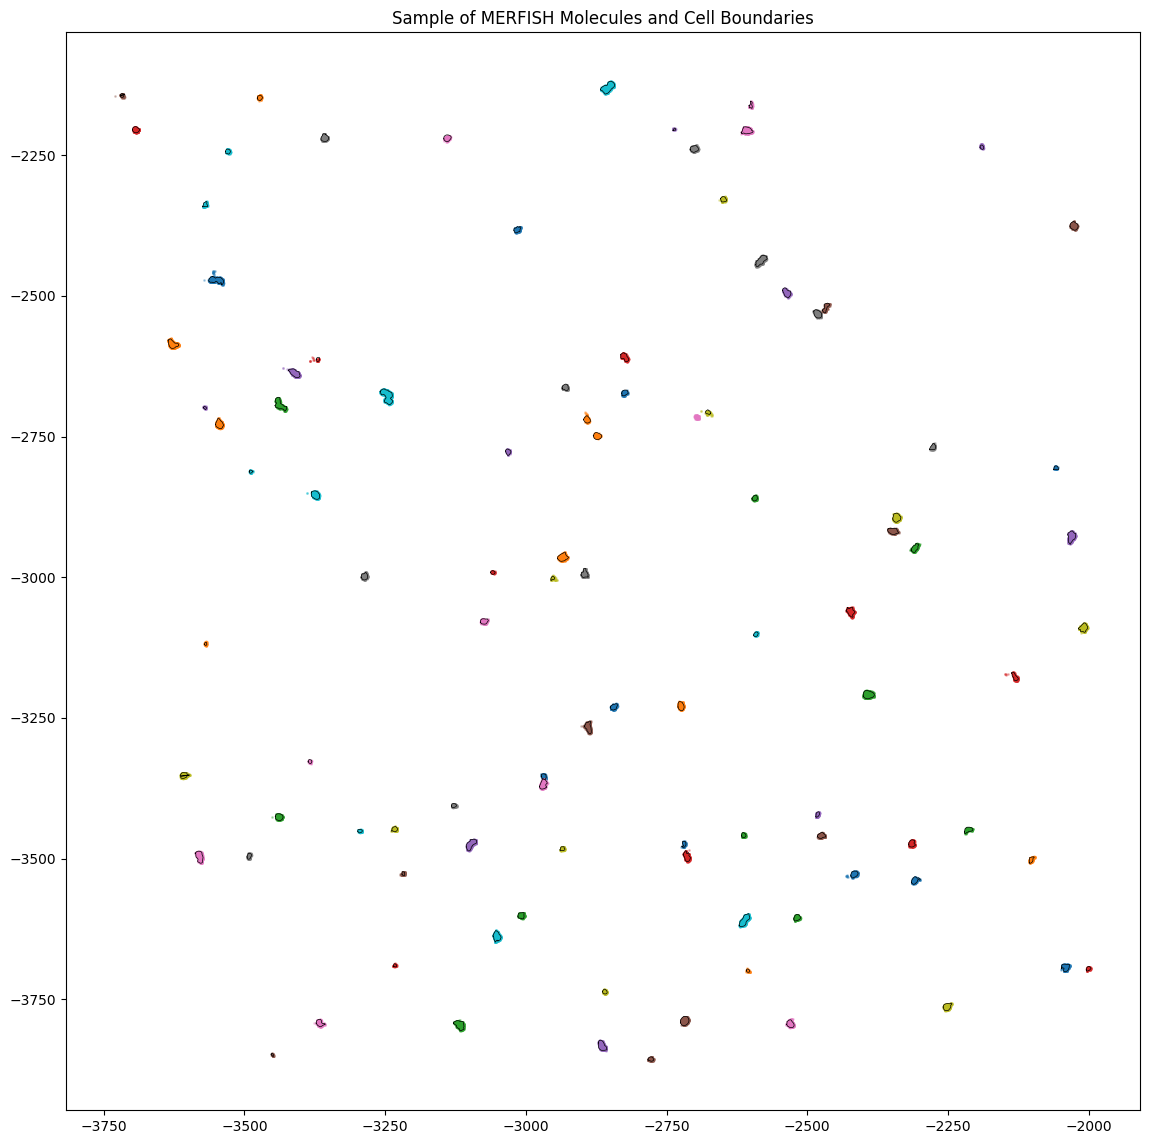

In [35]:
# Cell 9 Plot setup
fig, ax = plt.subplots(figsize=(14, 14))

# Plot a sample of 100 cells
for cell_id in df_merged["Cell_name"].drop_duplicates().sample(100, random_state=1):
    group = df_merged[df_merged["Cell_name"] == cell_id]
    
    # Extract boundary
    x_val = group["boundaryX"].values[0]
    y_val = group["boundaryY"].values[0]

    try:
        if isinstance(x_val, str) and re.match(r'^\[.*\]$', x_val.strip()):
            x = ast.literal_eval(x_val)
        else:
            x = [float(v) for v in str(x_val).split(";")]
    except:
        x = []

    try:
        if isinstance(y_val, str) and re.match(r'^\[.*\]$', y_val.strip()):
            y = ast.literal_eval(y_val)
        else:
            y = [float(v) for v in str(y_val).split(";")]
    except:
        y = []

    # Plot boundary if valid
    if x and y and len(x) == len(y):
        ax.plot(x, y, color="black", linewidth=0.5)

    # Plot molecule centroids
    ax.scatter(group["Centroid_X"], group["Centroid_Y"], s=1, alpha=0.3)

ax.set_title("Sample of MERFISH Molecules and Cell Boundaries")
ax.set_aspect("equal")
plt.show()
